# Laboratory Work №1

## Topic
Introduction to basic machine learning concepts

## Goal of the work
The purpose of this laboratory work is to study the basic concepts of machine learning, perform visual analysis of data, build a binary classification model using Logistic Regression, and demonstrate the overfitting problem using linear regression.

## Git repository
(https://github.com/kanaanhussein1991-rgb/LAb1)

## Theoretical warm-up

### 1. What is the main problem of overfitting?
The main problem of overfitting is that the model learns not only the general patterns in the training data, but also noise and random fluctuations. As a result, the model performs very well on the training set but poorly on new unseen data.

### 2. Why can’t we evaluate model quality on the same data it was trained on?
We cannot evaluate the model on the training data because the model may memorize this data. In this case, the evaluation result will be too optimistic and will not reflect the model’s true ability to generalize to new examples.

### 3. What is regularization and how does it help fight model complexity?
Regularization is a method that reduces model complexity by adding a penalty for large parameter values. It helps prevent overfitting, makes the model simpler, and improves its performance on unseen data.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

sns.set(style="whitegrid")

In [4]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [5]:
print("Dataset shape:", df.shape)
print("\nFeature names:")
print(df.columns.tolist())

print("\nClass distribution:")
print(df["species"].value_counts())

df.describe()

Dataset shape: (150, 6)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target', 'species']

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


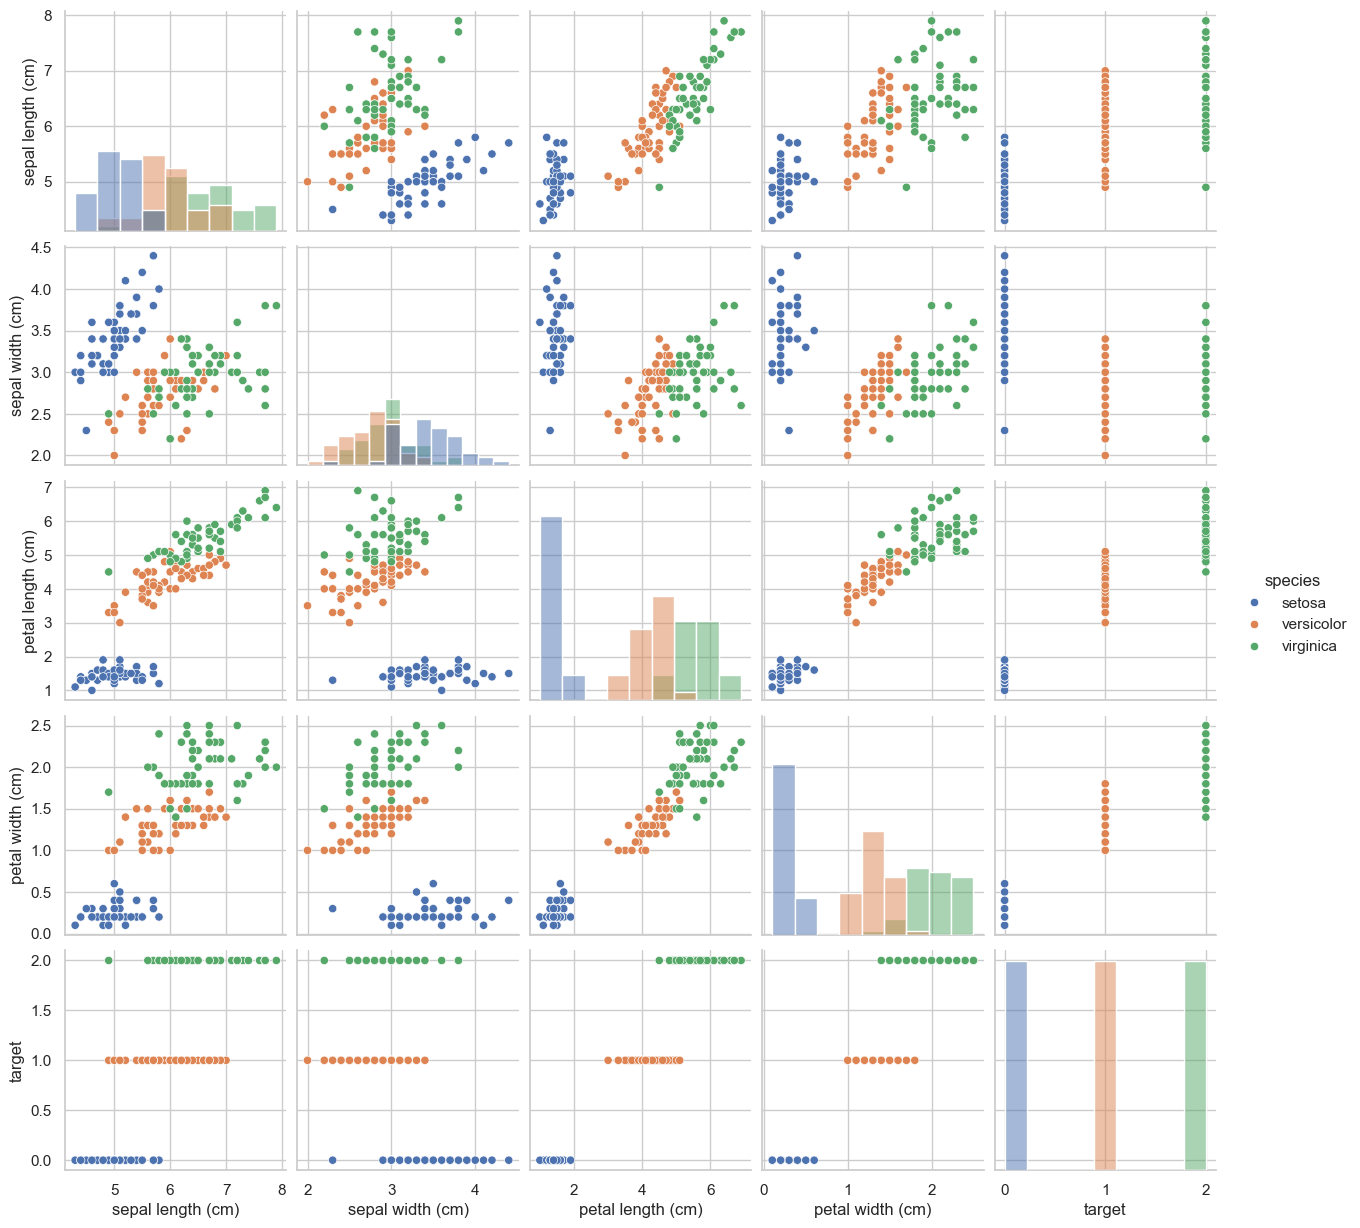

In [6]:
sns.pairplot(df, hue="species", diag_kind="hist")
plt.show()

## Visual analysis of the Iris dataset

The pairplot allows us to analyze the relationships between all numerical features in the Iris dataset.

We can observe that:
- The **setosa** class is clearly separated from the other classes in many feature combinations.
- The features **petal length** and **petal width** are especially useful for distinguishing classes.
- The classes **versicolor** and **virginica** overlap in some areas, so classification between them is more difficult than classification involving setosa.

Thus, visual analysis shows that the dataset is suitable for classification tasks.

In [7]:
binary_df = df[df["target"].isin([0, 1])].copy()

print(binary_df["species"].value_counts())
binary_df.head()

species
setosa        50
versicolor    50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [8]:
X = binary_df[iris.feature_names]
y = binary_df["target"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 70
Test set size: 30


In [10]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
y_pred = log_reg.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["setosa", "versicolor"]))

Accuracy: 1.0

Confusion Matrix:
[[15  0]
 [ 0 15]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Binary classification using Logistic Regression

For binary classification, only two classes were selected: **setosa** and **versicolor**.

The dataset was split into training and test sets. Then a Logistic Regression model was trained on the training data and evaluated on the test data.

The model achieved high accuracy, which indicates that these two classes are well separated. This result is consistent with the visual analysis obtained from the pairplot.

In [12]:
np.random.seed(42)

X = np.sort(np.random.rand(30))
y = np.sin(2 * np.pi * X) + np.random.normal(0, 0.15, size=30)

X = X.reshape(-1, 1)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 21
Test samples: 9


In [14]:
degrees = [1, 3, 10, 15]

train_errors = []
test_errors = []

for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_errors.append(train_mse)
    test_errors.append(test_mse)
    
    print(f"Degree {degree}")
    print("Train MSE:", train_mse)
    print("Test MSE:", test_mse)
    print("-" * 30)

Degree 1
Train MSE: 0.2237896629336769
Test MSE: 0.23484478025101085
------------------------------
Degree 3
Train MSE: 0.016584751457052325
Test MSE: 0.021392673433252955
------------------------------
Degree 10
Train MSE: 0.00959210342761935
Test MSE: 2.2025026718564638
------------------------------
Degree 15
Train MSE: 0.008010115977599094
Test MSE: 184193.01439390104
------------------------------


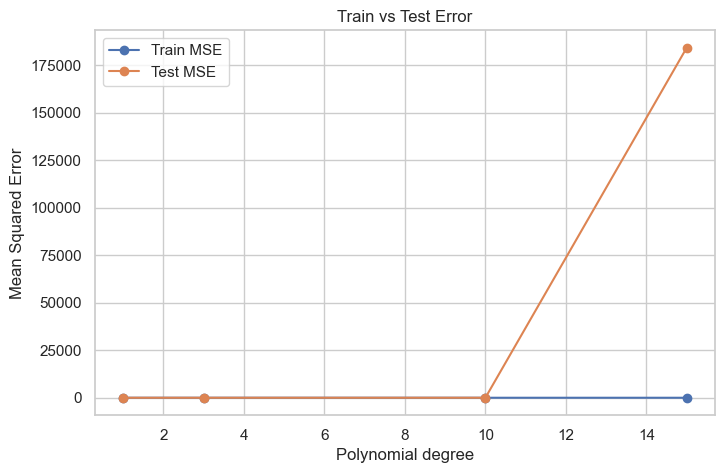

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_errors, marker='o', label='Train MSE')
plt.plot(degrees, test_errors, marker='o', label='Test MSE')
plt.xlabel("Polynomial degree")
plt.ylabel("Mean Squared Error")
plt.title("Train vs Test Error")
plt.legend()
plt.show()

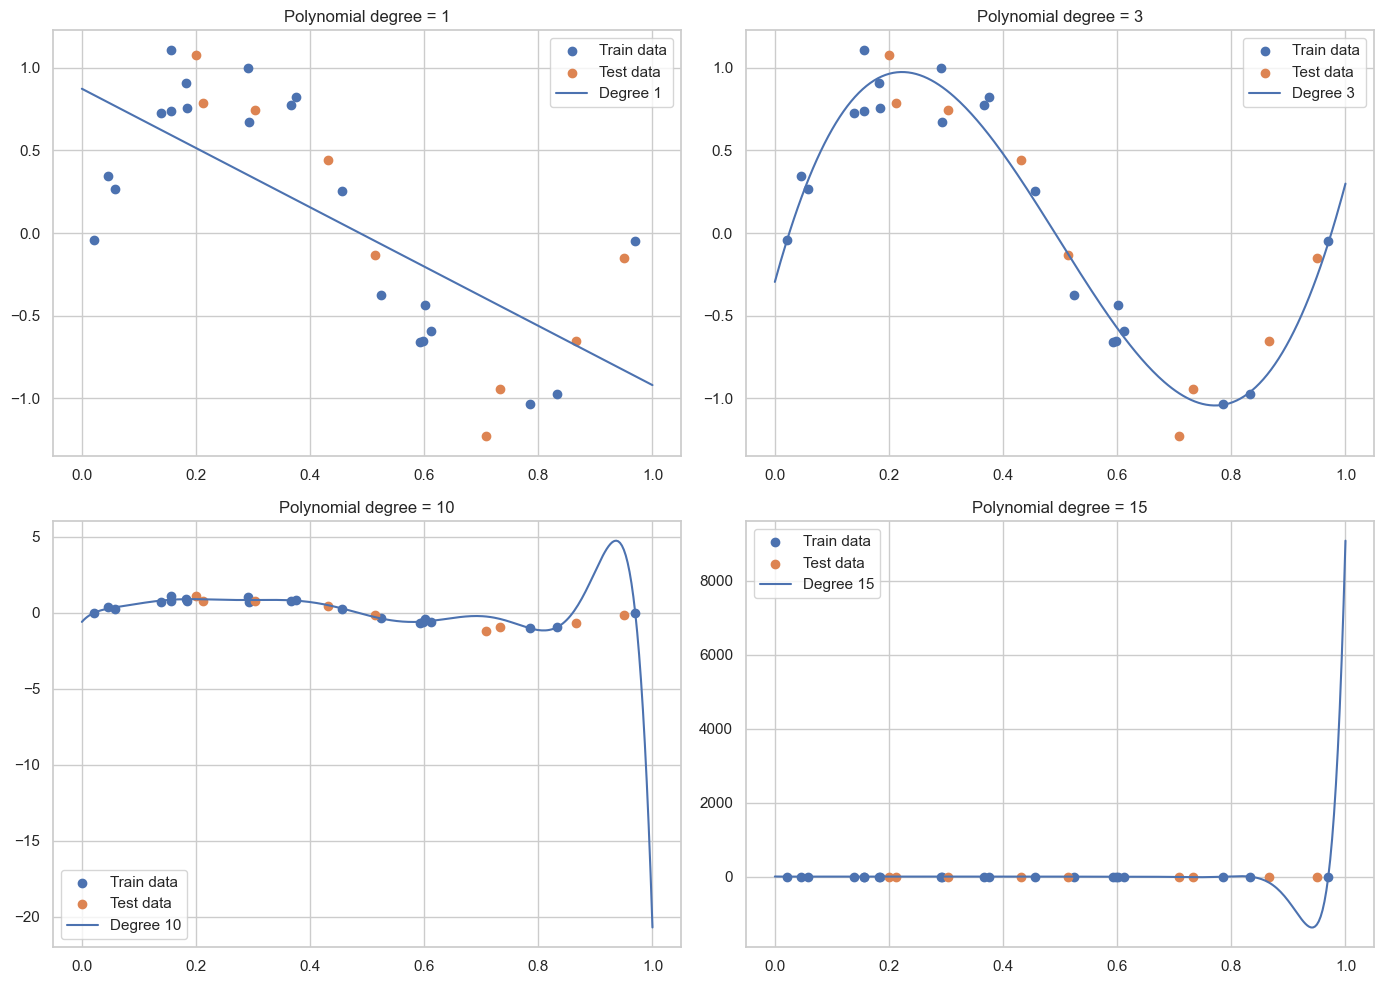

In [16]:
X_plot = np.linspace(0, 1, 300).reshape(-1, 1)

plt.figure(figsize=(14, 10))

for i, degree in enumerate(degrees, 1):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    y_plot = model.predict(X_plot)
    
    plt.subplot(2, 2, i)
    plt.scatter(X_train, y_train, label="Train data")
    plt.scatter(X_test, y_test, label="Test data")
    plt.plot(X_plot, y_plot, label=f"Degree {degree}")
    plt.title(f"Polynomial degree = {degree}")
    plt.legend()

plt.tight_layout()
plt.show()

## Demonstration of overfitting

To demonstrate overfitting, synthetic data was generated based on a nonlinear function with added noise.

Several polynomial regression models with different degrees were trained:
- Degree 1
- Degree 3
- Degree 10
- Degree 15

Results show that:
- Simple models may underfit the data and fail to capture the true relationship.
- A moderate degree provides a better balance between bias and variance.
- Very high-degree polynomials fit the training data extremely well but perform poorly on the test data.

This is a clear example of **overfitting**: the model becomes too complex, learns noise from the training set, and loses the ability to generalize.

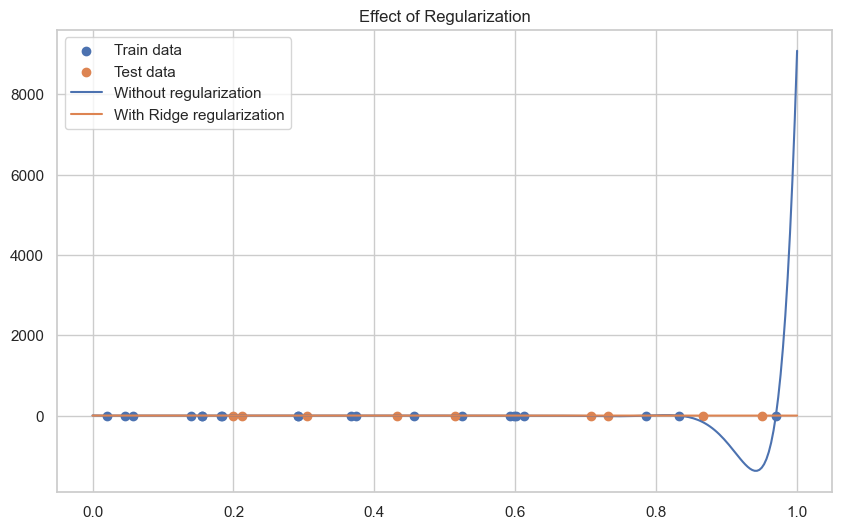

In [17]:
degree = 15

model_no_reg = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model_ridge = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=1.0))

model_no_reg.fit(X_train, y_train)
model_ridge.fit(X_train, y_train)

y_no_reg = model_no_reg.predict(X_plot)
y_ridge = model_ridge.predict(X_plot)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, label="Train data")
plt.scatter(X_test, y_test, label="Test data")
plt.plot(X_plot, y_no_reg, label="Without regularization")
plt.plot(X_plot, y_ridge, label="With Ridge regularization")
plt.title("Effect of Regularization")
plt.legend()
plt.show()

## Effect of regularization

Regularization helps reduce model complexity and prevents the model from fitting noise in the training data.

In this example, Ridge regularization makes the curve smoother and less sensitive to random fluctuations. As a result, the model becomes more stable and generalizes better to unseen data.

## Conclusion

In this laboratory work, the basic concepts of machine learning were studied.

The Iris dataset was loaded and analyzed visually using pairplot. This analysis showed that some classes are well separated, especially setosa.

A Logistic Regression model was built for binary classification, and the obtained results demonstrated high classification accuracy.

In addition, the overfitting problem was demonstrated using polynomial linear regression on synthetic data. It was shown that increasing model complexity too much leads to excellent performance on training data but poor performance on test data.

Finally, the role of regularization in reducing model complexity and improving generalization was demonstrated.